<a href="https://colab.research.google.com/github/ishwarihase/ML-projects/blob/main/uber.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


In [ ]:
df = pd.read_csv(
    "uber.csv",
    engine="python",
    on_bad_lines="skip"
)

print(df.shape)
print(df.head())



(292742, 9)
   Unnamed: 0                            key fare_amount  \
0    24238194    2015-05-07 19:52:06.0000003         7.5   
1    27835199    2009-07-17 20:04:56.0000002         7.7   
2    44984355   2009-08-24 21:45:00.00000061        12.9   
3    25894730    2009-06-26 08:22:21.0000001         5.3   
4    17610152  2014-08-28 17:47:00.000000188        16.0   

           pickup_datetime    pickup_longitude  pickup_latitude  \
0  2015-05-07 19:52:06 UTC  -73.99981689453125        40.738354   
1  2009-07-17 20:04:56 UTC          -73.994355        40.728225   
2  2009-08-24 21:45:00 UTC          -74.005043        40.740770   
3  2009-06-26 08:22:21 UTC          -73.976124        40.790844   
4  2014-08-28 17:47:00 UTC          -73.925023        40.744085   

   dropoff_longitude  dropoff_latitude  passenger_count  
0         -73.999512         40.723217              1.0  
1         -73.994710         40.750325              1.0  
2         -73.962565         40.772647            

In [ ]:
df = df.drop(columns=["key"])


In [ ]:
df["pickup_datetime"] = pd.to_datetime(
    df["pickup_datetime"],
    errors="coerce"
)


In [ ]:
df["year"] = df["pickup_datetime"].dt.year
df["month"] = df["pickup_datetime"].dt.month
df["day"] = df["pickup_datetime"].dt.day
df["hour"] = df["pickup_datetime"].dt.hour
df["day_of_week"] = df["pickup_datetime"].dt.dayofweek


In [ ]:
df = df.drop(columns=["pickup_datetime"])


In [ ]:
# Convert numeric columns to numeric datatype
df["fare_amount"] = pd.to_numeric(
    df["fare_amount"],
    errors="coerce"
)

df["passenger_count"] = pd.to_numeric(
    df["passenger_count"],
    errors="coerce"
)

df["pickup_longitude"] = pd.to_numeric(
    df["pickup_longitude"],
    errors="coerce"
)

df["pickup_latitude"] = pd.to_numeric(
    df["pickup_latitude"],
    errors="coerce"
)

df["dropoff_longitude"] = pd.to_numeric(
    df["dropoff_longitude"],
    errors="coerce"
)

df["dropoff_latitude"] = pd.to_numeric(
    df["dropoff_latitude"],
    errors="coerce"
)

In [ ]:
print(df.isnull().sum())

df = df.dropna()


Unnamed: 0           0
fare_amount          0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
year                 0
month                0
day                  0
hour                 0
day_of_week          0
dtype: int64


In [ ]:
df = df.drop_duplicates()


In [ ]:
df = df[df["fare_amount"] > 0]

# Passenger count must be positive
df = df[df["passenger_count"] > 0]

In [ ]:
# Valid geographical coordinate ranges
df = df[
    (df["pickup_longitude"].between(-180, 180)) &
    (df["dropoff_longitude"].between(-180, 180)) &
    (df["pickup_latitude"].between(-90, 90)) &
    (df["dropoff_latitude"].between(-90, 90))
]

In [ ]:
df = df[
    (df["pickup_longitude"].between(-75, -72)) &
    (df["dropoff_longitude"].between(-75, -72)) &
    (df["pickup_latitude"].between(40, 42)) &
    (df["dropoff_latitude"].between(40, 42))
]

print("\nShape after geographical filtering:", df.shape)


Shape after geographical filtering: (195092, 12)


In [ ]:
def haversine_distance(lat1, lon1, lat2, lon2):

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))

    earth_radius_km = 6371

    return earth_radius_km * c


df["distance_km"] = haversine_distance(
    df["pickup_latitude"],
    df["pickup_longitude"],
    df["dropoff_latitude"],
    df["dropoff_longitude"]
)


# ============================================================
# 10. REMOVE ZERO-DISTANCE TRIPS
# ============================================================

df = df[df["distance_km"] > 0]

print("\nShape after removing zero-distance trips:", df.shape)


Shape after removing zero-distance trips: (193056, 13)


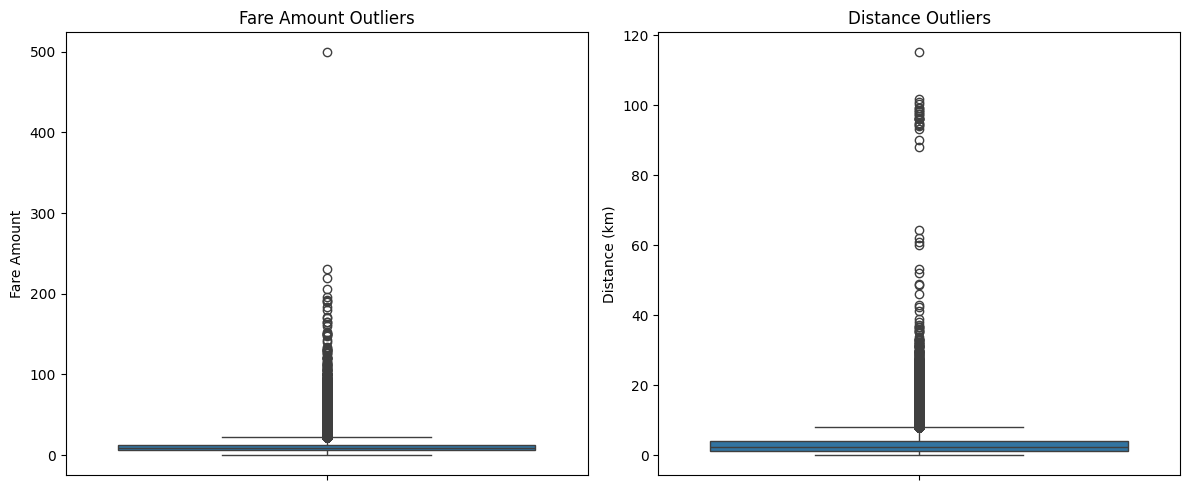

In [ ]:

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df["fare_amount"])
plt.title("Fare Amount Outliers")
plt.ylabel("Fare Amount")

plt.subplot(1, 2, 2)
sns.boxplot(y=df["distance_km"])
plt.title("Distance Outliers")
plt.ylabel("Distance (km)")

plt.tight_layout()
plt.show()

In [ ]:
def remove_outliers_iqr(data, column):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    return data[
        (data[column] >= lower_limit) &
        (data[column] <= upper_limit)
    ]


df = remove_outliers_iqr(df, "fare_amount")
df = remove_outliers_iqr(df, "distance_km")

print("\nShape after IQR outlier removal:", df.shape)


Shape after IQR outlier removal: (168795, 13)


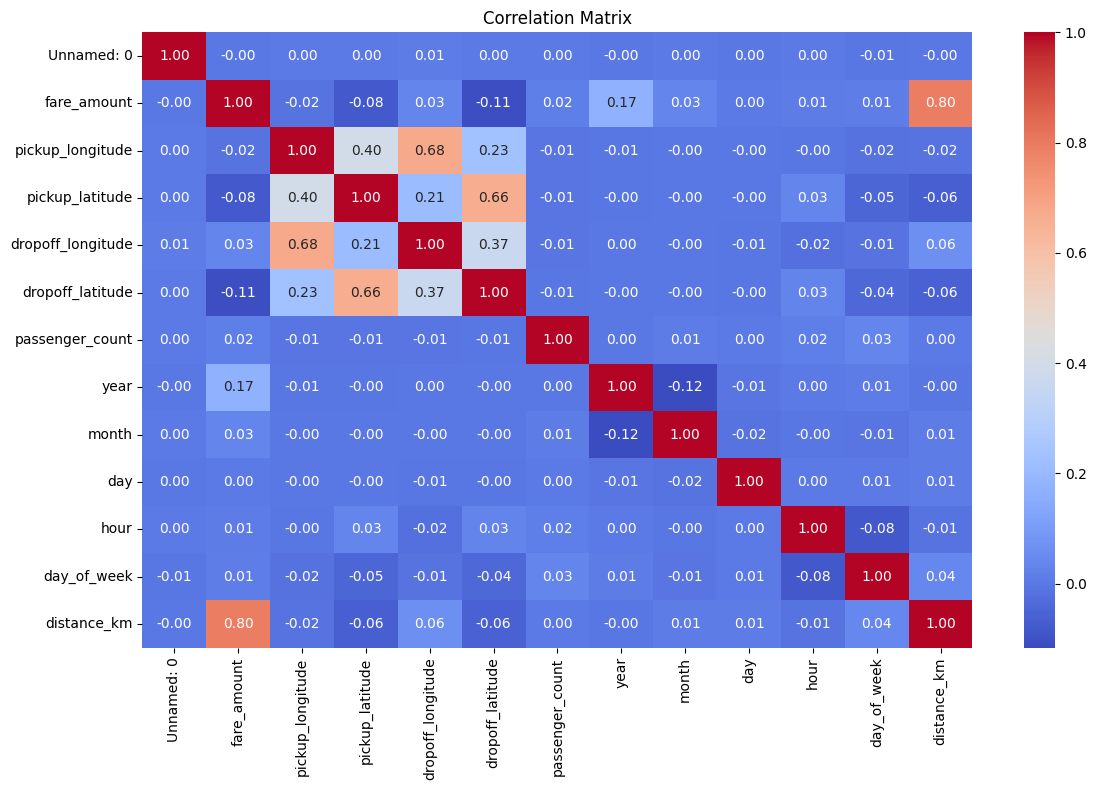

In [ ]:

correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


In [ ]:
print("\nCorrelation with Fare Amount:")

print(
    correlation_matrix["fare_amount"]
    .sort_values(ascending=False)
)


Correlation with Fare Amount:
fare_amount          1.000000
distance_km          0.795072
year                 0.173411
dropoff_longitude    0.034020
month                0.032720
passenger_count      0.016420
day_of_week          0.013116
hour                 0.006808
day                  0.004861
Unnamed: 0          -0.001897
pickup_longitude    -0.015291
pickup_latitude     -0.078068
dropoff_latitude    -0.109361
Name: fare_amount, dtype: float64


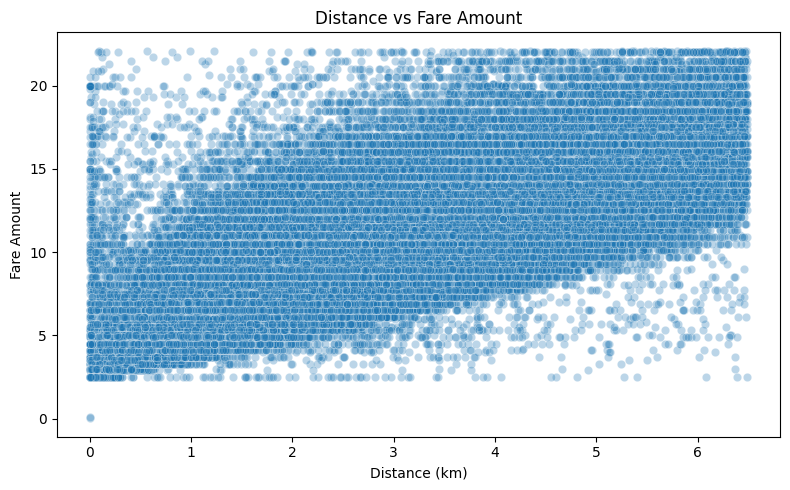

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="distance_km",
    y="fare_amount",
    alpha=0.3
)

plt.title("Distance vs Fare Amount")
plt.xlabel("Distance (km)")
plt.ylabel("Fare Amount")

plt.tight_layout()
plt.show()

In [ ]:

features = [
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude",
    "passenger_count",
    "year",
    "month",
    "day",
    "hour",
    "day_of_week",
    "distance_km"
]

X = df[features]
y = df["fare_amount"]

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (135036, 11)
Testing data: (33759, 11)


In [ ]:
# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Create model
linear_model = LinearRegression()

# Train model
linear_model.fit(
    X_train_scaled,
    y_train
)

# Prediction
linear_predictions = linear_model.predict(
    X_test_scaled
)


In [ ]:
mae_linear = mean_absolute_error(
    y_test,
    linear_predictions
)

rmse_linear = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

r2_linear = r2_score(
    y_test,
    linear_predictions
)

print("\n==============================")
print("LINEAR REGRESSION")
print("==============================")

print("MAE :", mae_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)


LINEAR REGRESSION
MAE : 1.5359926535726989
RMSE: 2.16819236561639
R²  : 0.6639016122260966


In [ ]:
random_forest_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

# Train model
random_forest_model.fit(
    X_train,
    y_train
)

# Prediction
rf_predictions = random_forest_model.predict(
    X_test
)


In [ ]:
mae_rf = mean_absolute_error(
    y_test,
    rf_predictions
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

r2_rf = r2_score(
    y_test,
    rf_predictions
)

print("\n==============================")
print("RANDOM FOREST REGRESSION")
print("==============================")

print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)


RANDOM FOREST REGRESSION
MAE : 1.318520958000204
RMSE: 1.9103608131095533
R²  : 0.7390834608723019


In [ ]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest Regression"
    ],

    "MAE": [
        mae_linear,
        mae_rf
    ],

    "RMSE": [
        rmse_linear,
        rmse_rf
    ],

    "R2 Score": [
        r2_linear,
        r2_rf
    ]
})

print("\n==============================")
print("MODEL COMPARISON")
print("==============================")

print(results)


MODEL COMPARISON
                      Model       MAE      RMSE  R2 Score
0         Linear Regression  1.535993  2.168192  0.663902
1  Random Forest Regression  1.318521  1.910361  0.739083


In [ ]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": random_forest_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\n==============================")
print("FEATURE IMPORTANCE")
print("==============================")

print(importance)


FEATURE IMPORTANCE
              Feature  Importance
10        distance_km    0.698015
5                year    0.052507
3    dropoff_latitude    0.045066
2   dropoff_longitude    0.040538
0    pickup_longitude    0.037479
1     pickup_latitude    0.032914
8                hour    0.031799
7                 day    0.020255
6               month    0.019095
9         day_of_week    0.015803
4     passenger_count    0.006529


In [ ]:
from ast import NodeVisitor
NodeVisitor


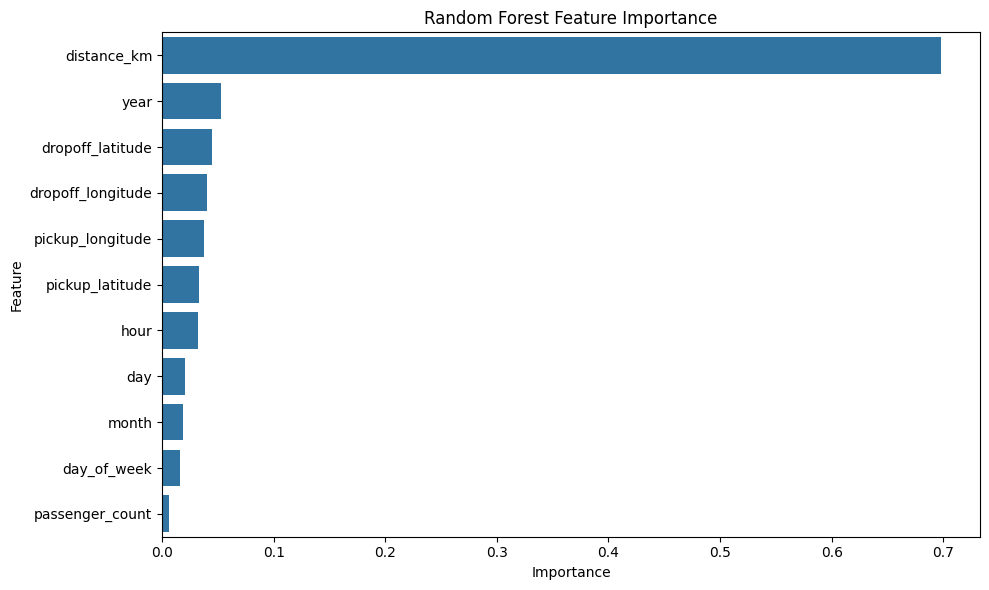

In [ ]:

plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()